In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path

df = pd.read_csv(r"C:\Users\ycode\OneDrive\Desktop\ClimaRisk\data\csvs\flood\flood.csv")

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":     120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#b0b0b0",
    "ytick.color":      "#e0e0e0",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2d3a",
})

FLOOD_COLOR  = "#ef4444"
SAFE_COLOR   = "#3b82f6"
ACCENT_COLOR = "#f59e0b"

initial_shape = df.shape
print(f"   Raw shape : {initial_shape[0]:,} rows × {initial_shape[1]} cols")
print(f"\n📋 Column overview:")
print(df.dtypes.to_string())
print(f"\n📊 Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or "   None found ✅")


   Raw shape : 1,025,801 rows × 16 cols

📋 Column overview:
date                  str
lon               float64
lat               float64
flooded           float64
jrc_perm_water    float64
precip_1d         float64
precip_3d         float64
NDVI              float64
NDWI              float64
landcover         float64
elevation         float64
slope             float64
aspect            float64
upstream_area     float64
TWI               float64
target              int64

📊 Missing values per column:
Series([], )


In [ ]:
before = len(df)
df = df.dropna()
print(f"   Null rows removed     : {before - len(df):,}")

before = len(df)
df = df.drop_duplicates()
print(f"   Duplicate rows removed: {before - len(df):,}")

keep_cols = [
    "lat", "lon", "precip_1d", "precip_3d", "NDVI", "NDWI",
    "jrc_perm_water",                          
    "landcover", "elevation", "slope", "upstream_area", "TWI", "target",
]
missing_cols = [c for c in keep_cols if c not in df.columns]
if missing_cols:
    print(f"     Missing columns (skipping): {missing_cols}")
    keep_cols = [c for c in keep_cols if c in df.columns]

df = df[keep_cols]
print(f"   Columns kept: {keep_cols}")

   Null rows removed     : 0
   Duplicate rows removed: 0
   Columns kept: ['lat', 'lon', 'precip_1d', 'precip_3d', 'NDVI', 'NDWI', 'jrc_perm_water', 'landcover', 'elevation', 'slope', 'upstream_area', 'TWI', 'target']


In [ ]:
print("\n🔍 Step 2 — Outlier detection...")

numeric_cols = [c for c in keep_cols if c not in ("lat", "lon", "landcover", "target")]

outlier_report = []
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report.append({
        "column": col, "Q1": Q1, "Q3": Q3,
        "IQR": IQR, "lower_fence": lo, "upper_fence": hi,
        "outlier_count": n_out,
        "outlier_pct": round(n_out / len(df) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_report)
print(outlier_df[["column", "outlier_count", "outlier_pct"]].to_string(index=False))

domain_caps = {
    "TWI":           (None, 15),
    "elevation":     (-50,  None),
    "slope":         (None, 80),
    "precip_1d":     (0,    500),
    "precip_3d":     (0,    800),
    "jrc_perm_water":(0,    1),    
}

before = len(df)
for col, (lo, hi) in domain_caps.items():
    if col not in df.columns:
        continue
    if lo is not None:
        df = df[df[col] >= lo]
    if hi is not None:
        df = df[df[col] <= hi]

print(f"\n   Domain-cap rows removed: {before - len(df):,}")


🔍 Step 2 — Outlier detection...
        column  outlier_count  outlier_pct
     precip_1d          19382         1.89
     precip_3d          20487         2.00
          NDVI          30024         2.93
          NDWI          23395         2.28
jrc_perm_water          95627         9.32
     elevation         164024        15.99
         slope         104202        10.16
 upstream_area         182161        17.76
           TWI          29778         2.90

   Domain-cap rows removed: 0


In [ ]:
before = len(df)
ghost_mask = (
    (df["target"] == 1)        &
    (df["precip_3d"] < 0.1)   &   
    (df["NDWI"]     < -0.3)   &   
    (df["TWI"]      < 2)          
)
df = df[~ghost_mask]
print(f"   Ghost floods removed : {before - len(df):,}")

   Ghost floods removed : 0


In [87]:
print("\n  Step 4 — Feature engineering...")

df["saturation_idx"]       = df["precip_3d"] * df["TWI"]

df["rain_burst_ratio"]     = (df["precip_1d"] / (df["precip_3d"] + 1e-6)).clip(0, 3)

df["topo_flood_potential"] = df["upstream_area"] / (df["slope"] + 1)

df["veg_absorption"]       = df["NDVI"].clip(0, 1) * (1 - df["NDWI"].clip(0, 1))

print("   New features: saturation_idx, rain_burst_ratio, topo_flood_potential, veg_absorption")

balance = df["target"].value_counts(normalize=True)
print(f"\n   Class balance → Flood: {balance.get(1,0):.1%}  Safe: {balance.get(0,0):.1%}")
total_removed = initial_shape[0] - len(df)
print(f"   Total rows removed: {total_removed:,} ({total_removed/initial_shape[0]:.1%} of original)")


  Step 4 — Feature engineering...
   New features: saturation_idx, rain_burst_ratio, topo_flood_potential, veg_absorption

   Class balance → Flood: 4.5%  Safe: 95.5%
   Total rows removed: 0 (0.0% of original)



📊 Step 5 — Generating EDA visualizations...


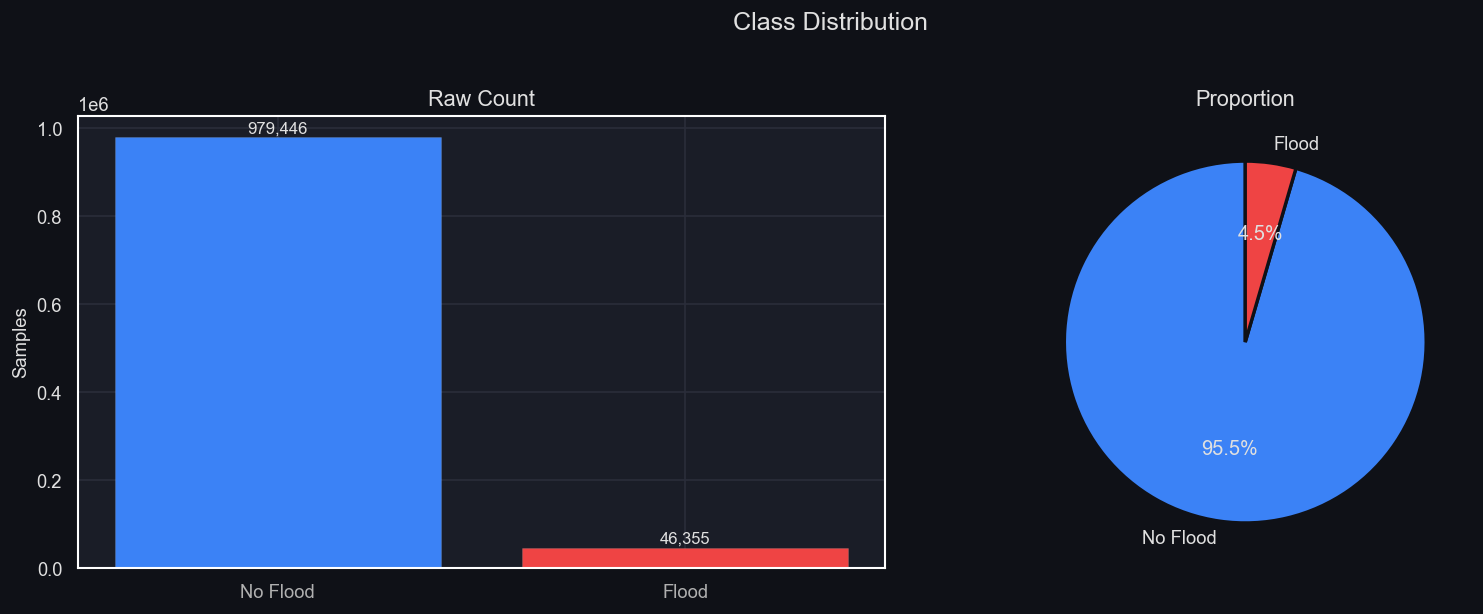

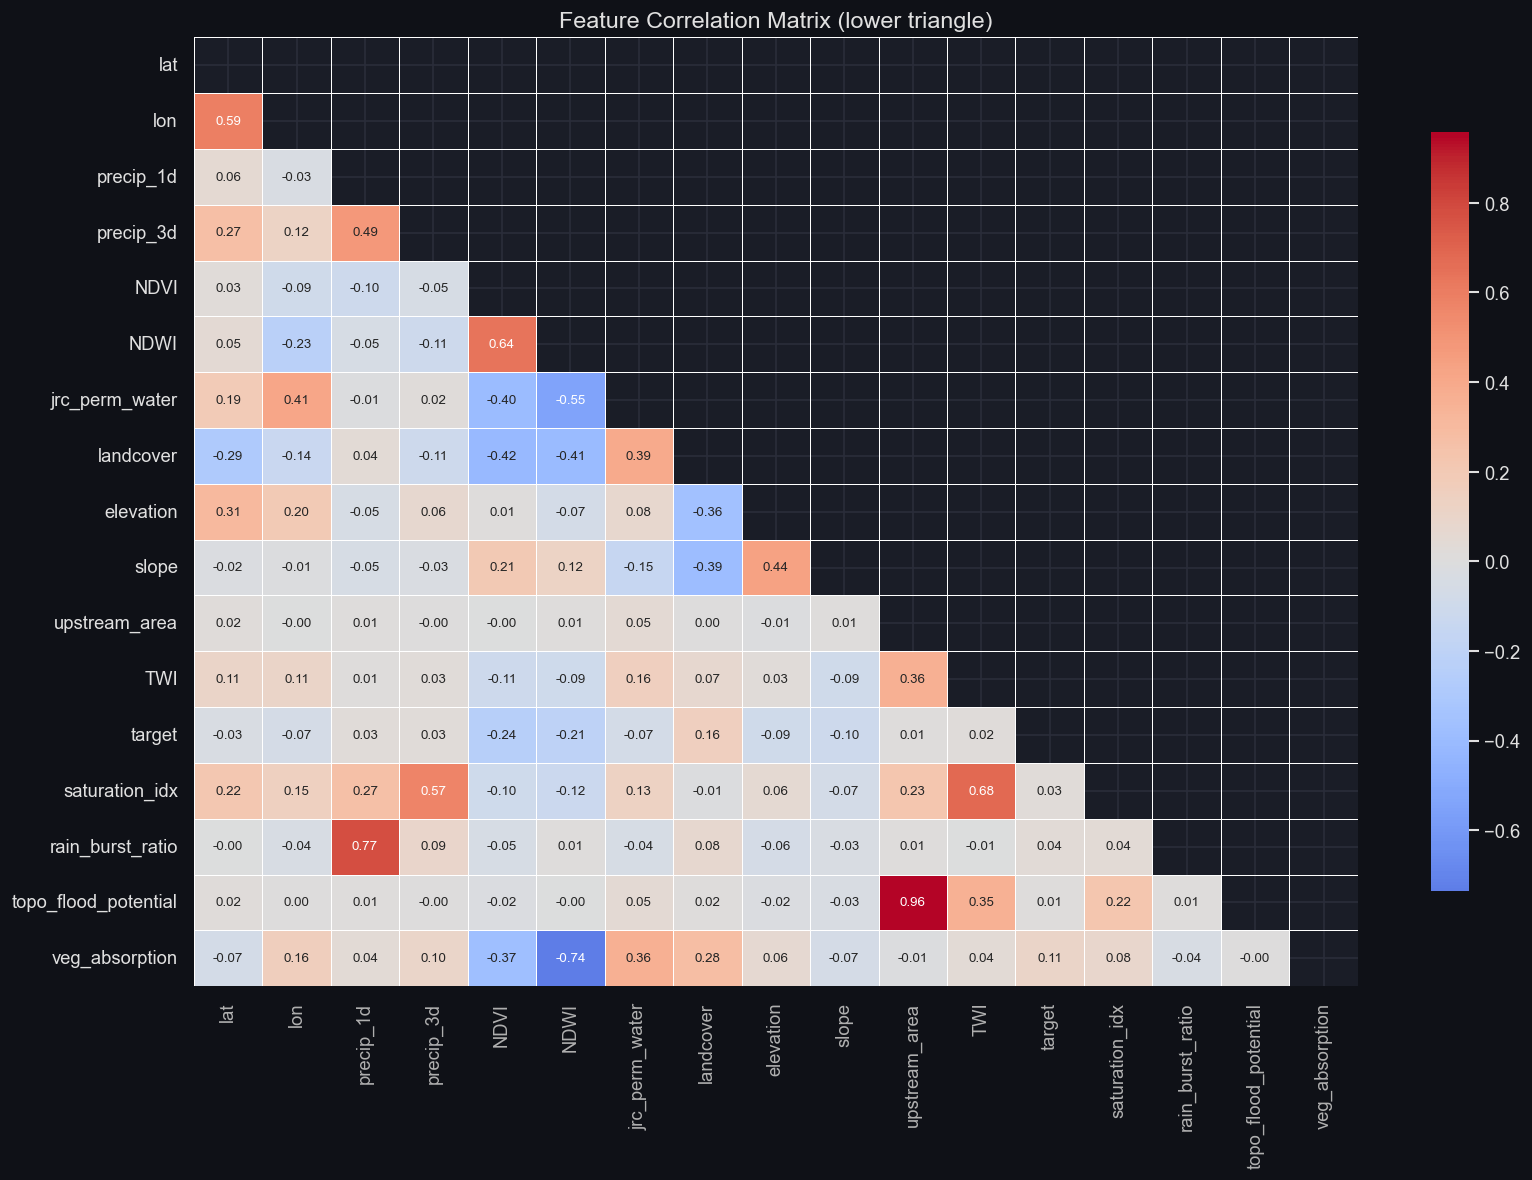

C:\Users\ycode\AppData\Local\Temp\ipykernel_34776\1290921452.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\ycode\AppData\Local\Temp\ipykernel_34776\1290921452.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\ycode\AppData\Local\Temp\ipykernel_34776\1290921452.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\ycode\AppData\Local\Temp\ipykernel_34776\1290921452.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will 

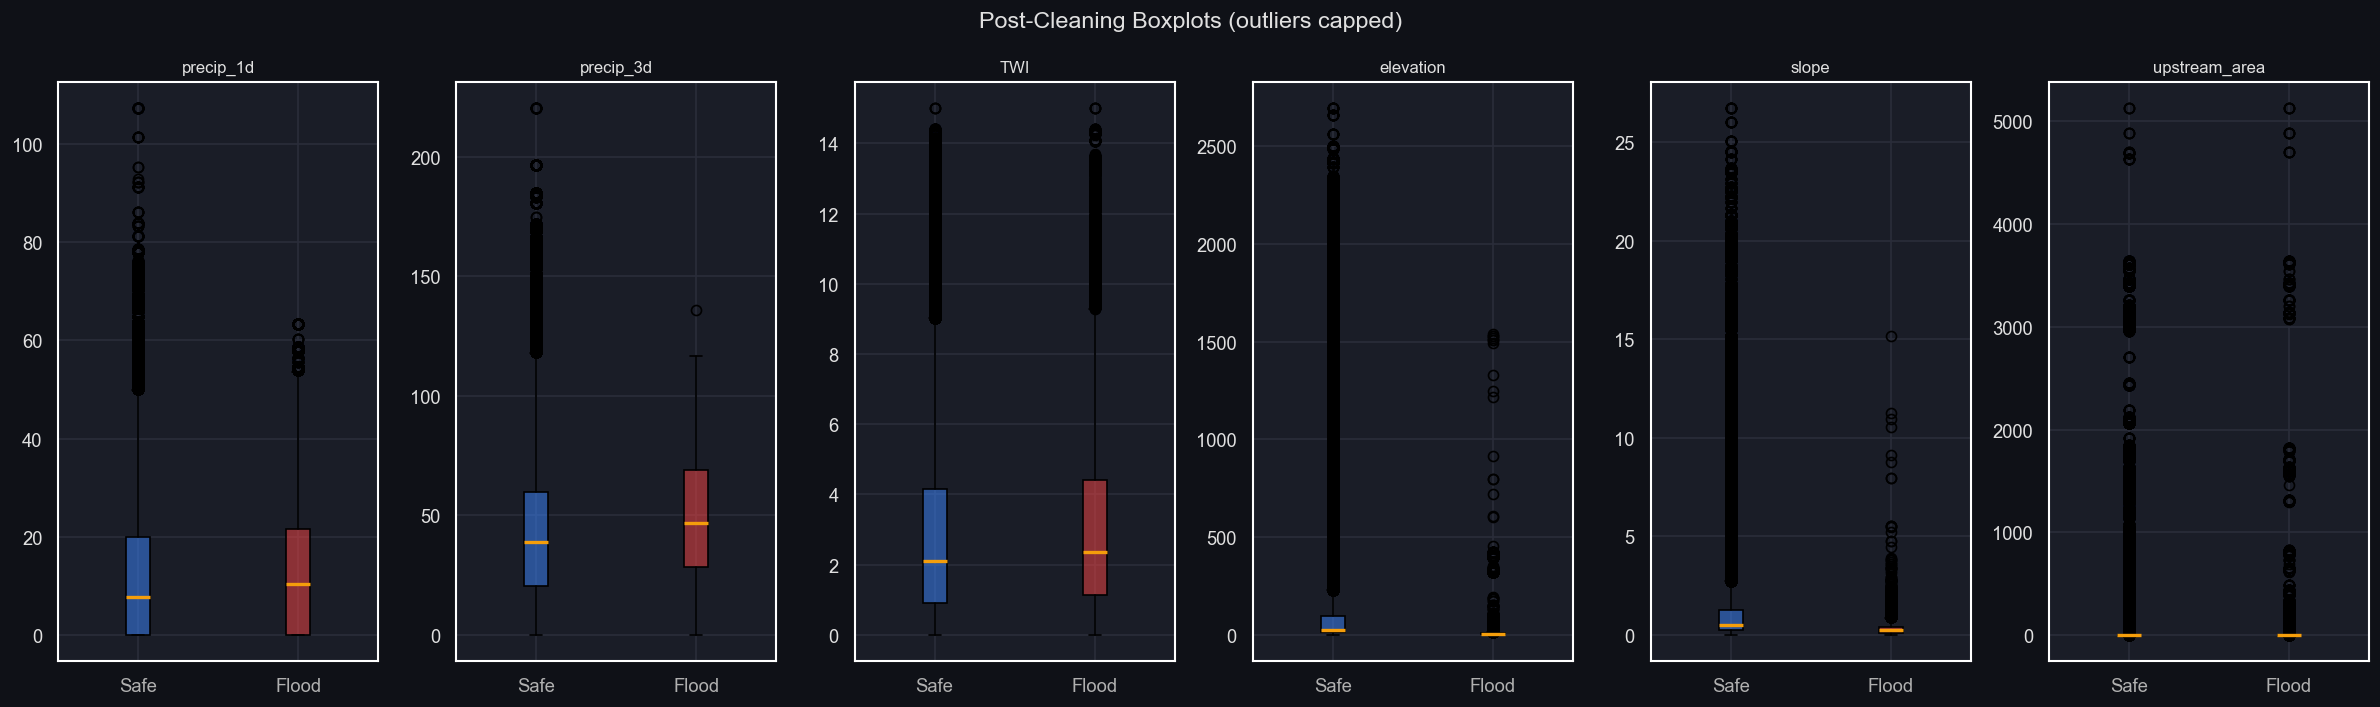

C:\Users\ycode\AppData\Local\Temp\ipykernel_34776\1290921452.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Flood", "Flood"])


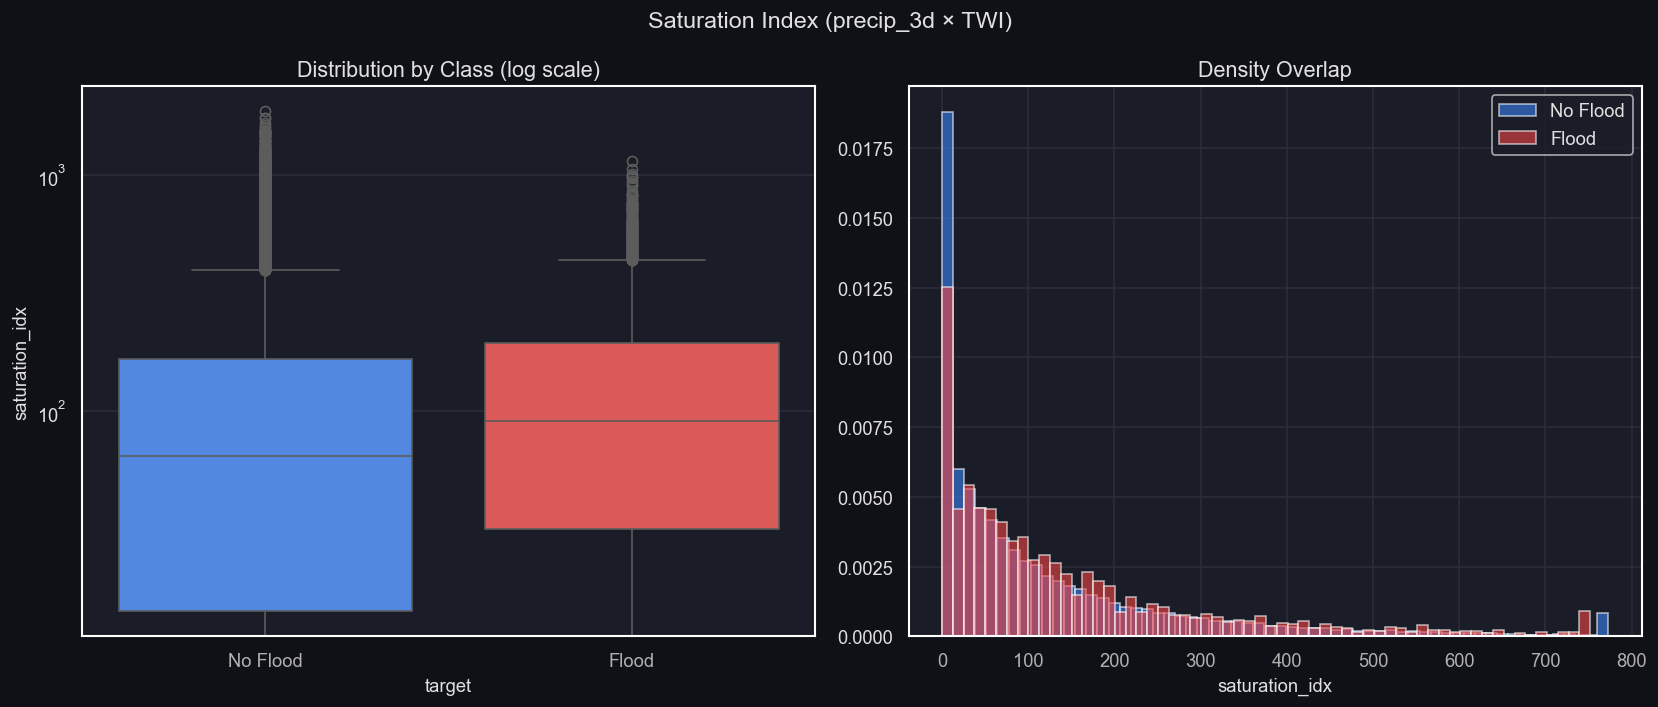


📈 Feature correlation with flood target (point-biserial):
                      correlation        p_value
NDVI                    -0.240955   0.000000e+00
NDWI                    -0.206790   0.000000e+00
veg_absorption           0.108506   0.000000e+00
slope                   -0.101513   0.000000e+00
elevation               -0.091978   0.000000e+00
jrc_perm_water          -0.069754   0.000000e+00
rain_burst_ratio         0.037179  1.625253e-310
saturation_idx           0.030978  3.448581e-216
precip_1d                0.030618  3.129506e-211
precip_3d                0.029440  1.937164e-195
TWI                      0.024514  4.026158e-136
topo_flood_potential     0.012714   6.066603e-38
upstream_area            0.006811   5.278317e-12


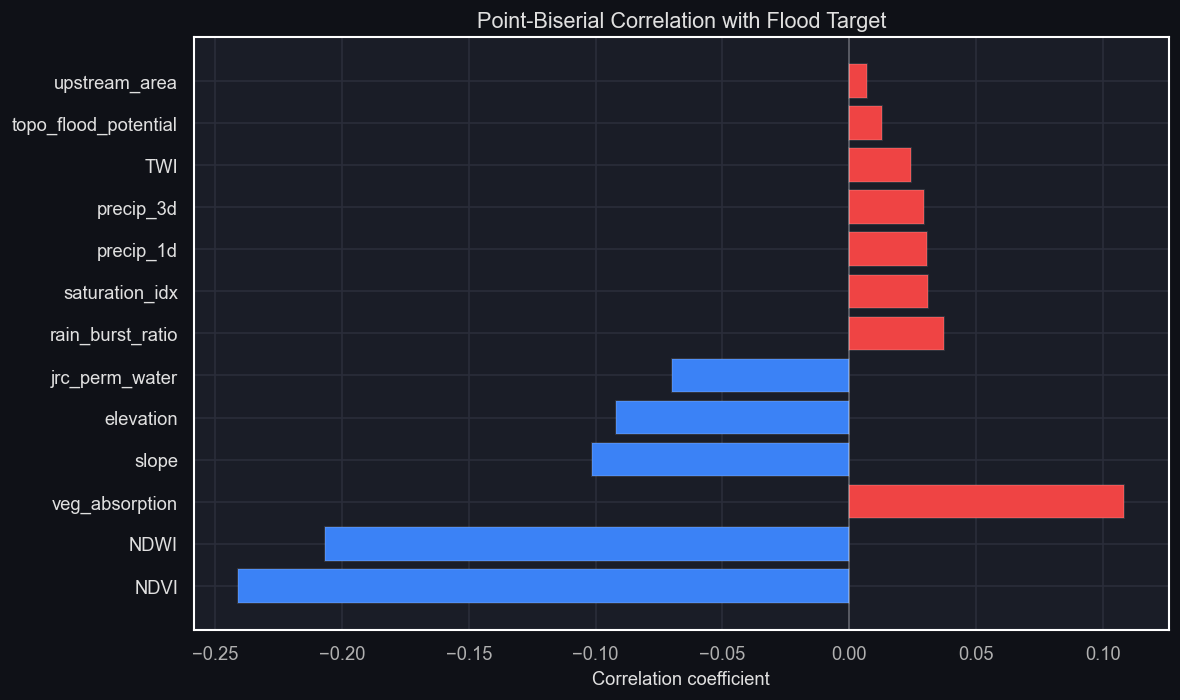

In [ ]:
print("\n📊 Step 5 — Generating EDA visualizations...")

df_sample = df.sample(n=min(50_000, len(df)), random_state=42)
flood_s = df_sample[df_sample["target"] == 1]
safe_s  = df_sample[df_sample["target"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution", fontsize=15, color="#e0e0e0", y=1.02)

counts = df["target"].value_counts()
axes[0].bar(["No Flood", "Flood"], counts.values,
            color=[SAFE_COLOR, FLOOD_COLOR], edgecolor="#ffffff22", linewidth=0.5)
axes[0].set_title("Raw Count")
axes[0].set_ylabel("Samples")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + counts.max()*0.01, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(counts.values, labels=["No Flood", "Flood"],
            colors=[SAFE_COLOR, FLOOD_COLOR], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "#0f1117", "linewidth": 2})
axes[1].set_title("Proportion")
plt.tight_layout()
plt.show()

plot_features = ["precip_1d", "precip_3d", "TWI", "elevation",
                 "slope", "saturation_idx", "NDVI", "NDWI"]
plot_features = [f for f in plot_features if f in df.columns]


fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.3,
            annot_kws={"size": 8}, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix (lower triangle)", fontsize=14)
plt.tight_layout()
plt.show()

box_features = ["precip_1d", "precip_3d", "TWI", "elevation", "slope", "upstream_area"]
box_features = [f for f in box_features if f in df.columns]

fig, axes = plt.subplots(1, len(box_features), figsize=(20, 6))
fig.suptitle("Post-Cleaning Boxplots (outliers capped)", fontsize=14, color="#e0e0e0")

for i, feat in enumerate(box_features):
    bp = axes[i].boxplot(
        [df[df["target"]==0][feat].dropna(),
         df[df["target"]==1][feat].dropna()],
        labels=["Safe", "Flood"],
        patch_artist=True,
        medianprops={"color": ACCENT_COLOR, "linewidth": 2},
    )
    bp["boxes"][0].set_facecolor(SAFE_COLOR + "88")
    bp["boxes"][1].set_facecolor(FLOOD_COLOR + "88")
    axes[i].set_title(feat, fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Saturation Index (precip_3d × TWI)", fontsize=14, color="#e0e0e0")

sns.boxplot(
    x="target",
    y="saturation_idx",
    hue="target",
    data=df_sample,
    palette={0: SAFE_COLOR, 1: FLOOD_COLOR},
    dodge=False,
    legend=False,
    ax=axes[0]
)

axes[0].set_yscale("log")
axes[0].set_xticklabels(["No Flood", "Flood"])
axes[0].set_title("Distribution by Class (log scale)")

axes[1].hist(safe_s["saturation_idx"].clip(upper=safe_s["saturation_idx"].quantile(0.99)),
             bins=60, alpha=0.6, color=SAFE_COLOR, density=True, label="No Flood")
axes[1].hist(flood_s["saturation_idx"].clip(upper=flood_s["saturation_idx"].quantile(0.99)),
             bins=60, alpha=0.6, color=FLOOD_COLOR, density=True, label="Flood")
axes[1].set_title("Density Overlap")
axes[1].set_xlabel("saturation_idx")
axes[1].legend()
plt.tight_layout()
plt.show()



print("\n📈 Feature correlation with flood target (point-biserial):")
correlations = {}
for col in [c for c in df.columns if c not in ("lat", "lon", "landcover", "target")]:
    corr_val, p_val = stats.pointbiserialr(df["target"], df[col].fillna(0))
    correlations[col] = {"correlation": corr_val, "p_value": p_val}

corr_df = pd.DataFrame(correlations).T
corr_df = corr_df.sort_values("correlation", key=abs, ascending=False)
print(corr_df.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors = [FLOOD_COLOR if v > 0 else SAFE_COLOR for v in corr_df["correlation"]]
ax.barh(corr_df.index, corr_df["correlation"], color=colors, edgecolor="#ffffff22")
ax.axvline(0, color="#ffffff44", linewidth=1)
ax.set_title("Point-Biserial Correlation with Flood Target", fontsize=13)
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

In [ ]:
CLEANED_PATH = r"C:\Users\ycode\OneDrive\Desktop\ClimaRisk\data\csvs\flood\flood_cleaned.csv"
df.to_csv(CLEANED_PATH, index=False)

print("\n" + "="*60)
print(" CLEANING COMPLETE")
print("="*60)
print(f"   Original shape : {initial_shape[0]:,} × {initial_shape[1]}")
print(f"   Final shape    : {df.shape[0]:,} × {df.shape[1]}")
print(f"   Rows removed   : {initial_shape[0] - df.shape[0]:,} ({(initial_shape[0]-df.shape[0])/initial_shape[0]:.1%})")
print(f"   New features   : saturation_idx, rain_burst_ratio, topo_flood_potential, veg_absorption")
print(f"\n   Class balance:")
print(f"   {df['target'].value_counts().to_string()}")
print(f"\n Saved → {CLEANED_PATH}")


✅ CLEANING COMPLETE
   Original shape : 1,025,801 × 16
   Final shape    : 1,025,801 × 17
   Rows removed   : 0 (0.0%)
   New features   : saturation_idx, rain_burst_ratio, topo_flood_potential, veg_absorption

   Class balance:
   target
0    979446
1     46355

💾 Saved → C:\Users\ycode\OneDrive\Desktop\ClimaRisk\data\csvs\flood\flood_cleaned.csv
